# Project 2 Pipeline: Predicting Pitcher xERA with Statcast Pitch-Quality Metrics

This notebook implements the problem solution pipeline for DS 4320 Project 2. The pipeline connects to MongoDB, queries the pitcher-season Statcast collection, converts the documents into a pandas dataframe, cleans the modeling data, trains a machine learning model, evaluates performance, and creates a visualization comparing actual and predicted xERA.

The specific problem is:

**How well can pitcher-season Statcast pitch-quality metrics from the 2018–2021 MLB seasons predict season-level xERA for qualified pitchers?**

In [ ]:
!pip install pandas numpy matplotlib scikit-learn pymongo python-dotenv

In [3]:
import os
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pymongo import MongoClient
from dotenv import load_dotenv

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

os.makedirs("logs", exist_ok=True)

log_file = "logs/project2_pipeline.log"

logging.basicConfig(
    filename=log_file,
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True
)

logging.info("Pipeline started successfully.")

print(f"Log file created at: {log_file}")

Log file created at: logs/project2_pipeline.log


In [4]:
from pymongo import MongoClient

MONGO_URI = "removed for submission"

try:
    client = MongoClient(MONGO_URI)
    db = client["project_2"]
    collection = db["pitcher_season_model_data"]

    document_count = collection.count_documents({})
    print(f"Connected to MongoDB. Documents in collection: {document_count}")

    logging.info(f"Connected to MongoDB. Documents in collection: {document_count}")

except Exception as e:
    logging.error(f"MongoDB connection failed: {e}")
    raise

Connected to MongoDB. Documents in collection: 2967


## 2. Query MongoDB into a DataFrame

The MongoDB collection stores one document per pitcher-season observation. This query loads the documents and converts them into a pandas dataframe for analysis.

In [5]:
try:
    documents = list(collection.find({}))
    df = pd.DataFrame(documents)

    print("Initial dataframe shape:", df.shape)
    display(df.head())

    logging.info(f"Loaded dataframe with shape {df.shape}")

except Exception as e:
    logging.error(f"Failed to load MongoDB documents into dataframe: {e}")
    raise

Initial dataframe shape: (2967, 9)


,_id,pitcher_id,pitcher_name,season,xERA,avg_estimated_woba,plate_appearances,fastball_velocity,fastball_spin
0,69ebc1c26aeae905745c854e,572971,"Keuchel, Dallas",2018,3.60,0.293,874,89.7,2166.0
1,69ebc1c26aeae905745c854f,448306,"Shields, James",2018,5.33,0.350,871,89.5,2271.0
2,69ebc1c26aeae905745c8550,453286,"Scherzer, Max",2018,2.56,0.248,866,94.4,2487.0
3,69ebc1c26aeae905745c8551,607536,"Freeland, Kyle",2018,3.76,0.299,844,91.8,2267.0
4,69ebc1c26aeae905745c8552,446372,"Kluber, Corey",2018,3.18,0.276,842,92.0,2410.0


In [6]:
# Remove MongoDB object ID because it is not useful for modeling
if "_id" in df.columns:
    df = df.drop(columns=["_id"])

print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['pitcher_id', 'pitcher_name', 'season', 'xERA', 'avg_estimated_woba', 'plate_appearances', 'fastball_velocity', 'fastball_spin']


## 3. Data Cleaning

The model uses fastball velocity and fastball spin to predict xERA. Rows with missing values in these required fields are removed before modeling.

In [7]:
required_columns = [
    "pitcher_id",
    "pitcher_name",
    "season",
    "xERA",
    "avg_estimated_woba",
    "plate_appearances",
    "fastball_velocity",
    "fastball_spin"
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

model_df = df[required_columns].copy()

numeric_columns = ["season", "xERA", "fastball_velocity", "fastball_spin"]

for col in numeric_columns:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

before_drop = model_df.shape[0]
model_df = model_df.dropna(subset=["xERA", "fastball_velocity", "fastball_spin"])
after_drop = model_df.shape[0]

print(f"Rows before cleaning: {before_drop}")
print(f"Rows after cleaning: {after_drop}")
print(f"Rows dropped: {before_drop - after_drop}")

display(model_df.head())

logging.info(f"Rows before cleaning: {before_drop}")
logging.info(f"Rows after cleaning: {after_drop}")

Rows before cleaning: 2967
Rows after cleaning: 2967
Rows dropped: 0


,pitcher_id,pitcher_name,season,xERA,avg_estimated_woba,plate_appearances,fastball_velocity,fastball_spin
0,572971,"Keuchel, Dallas",2018,3.60,0.293,874,89.7,2166.0
1,448306,"Shields, James",2018,5.33,0.350,871,89.5,2271.0
2,453286,"Scherzer, Max",2018,2.56,0.248,866,94.4,2487.0
3,607536,"Freeland, Kyle",2018,3.76,0.299,844,91.8,2267.0
4,446372,"Kluber, Corey",2018,3.18,0.276,842,92.0,2410.0


## 4. Exploratory Summary

This section summarizes the final modeling dataset and checks the distribution of the main variables.

In [8]:
summary_stats = model_df[["xERA", "fastball_velocity", "fastball_spin"]].describe()

display(summary_stats)

,xERA,fastball_velocity,fastball_spin
count,2967.000000,2967.000000,2967.000000
mean,5.492727,92.975598,2255.469161
std,6.217268,2.953280,162.000938
min,0.000000,64.000000,1448.000000
25%,3.680000,91.500000,2150.000000
50%,4.510000,93.200000,2257.000000
75%,5.770000,94.700000,2364.000000
max,190.840000,101.000000,2891.000000


In [9]:
print("Number of pitcher-season observations:", len(model_df))
print("Number of unique pitchers:", model_df["pitcher_id"].nunique())
print("Seasons included:", sorted(model_df["season"].unique()))

Number of pitcher-season observations: 2967
Number of unique pitchers: 1271
Seasons included: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]


## 5. Feature Selection

The prediction target is `xERA`. The explanatory variables are:

- `fastball_velocity`
- `fastball_spin`
- `season`

Velocity and spin rate are core Statcast pitch-quality variables. Season is included to account for year-to-year differences across the 2018–2021 period.

In [10]:
features = [
    "avg_estimated_woba",
    "plate_appearances",
    "fastball_velocity",
    "fastball_spin"
]

target = "xERA"

X = model_df[features]
y = model_df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (2967, 4)
Target shape: (2967,)


## 6. Train/Test Split

The data is split into training and testing sets. The model is trained on 80% of the pitcher-season observations and evaluated on the remaining 20%.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 2373
Testing rows: 594


## 7. Baseline Model: Linear Regression

Linear regression is used as a baseline model because it is simple, interpretable, and useful for understanding the direction of relationships between Statcast pitch-quality variables and xERA.

In [12]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("MAE:", round(linear_mae, 4))
print("RMSE:", round(linear_rmse, 4))
print("R²:", round(linear_r2, 4))

logging.info("Linear regression model trained.")
logging.info(f"Linear MAE: {linear_mae}")
logging.info(f"Linear RMSE: {linear_rmse}")
logging.info(f"Linear R2: {linear_r2}")

Linear Regression Results
MAE: 1.4226
RMSE: 2.0328
R²: 0.6816


The updated model shows a substantial improvement in predictive performance compared to the baseline specification. The inclusion of avg_estimated_woba significantly increases the model’s explanatory power, resulting in an R² of approximately 0.68. This indicates that the model is able to explain a large portion of the variation in pitcher xERA.

The reduction in RMSE and MAE further suggests that predictions are meaningfully closer to actual values. This improvement highlights the importance of including contact-quality metrics when modeling pitcher performance. While velocity and spin rate provide useful information about pitch characteristics, they are not sufficient on their own to explain outcomes.

The results demonstrate that expected contact metrics, such as estimated wOBA, play a critical role in predicting run prevention, as they capture the quality of interactions between pitchers and hitters.

In [13]:
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": linear_model.coef_
})

display(coef_df)

,feature,coefficient
0,avg_estimated_woba,68.530549
1,plate_appearances,0.000429
2,fastball_velocity,0.041271
3,fastball_spin,0.000774


## 8. Machine Learning Model: Random Forest Regressor

A Random Forest Regressor is used as the main machine learning model. This model can capture nonlinear relationships between pitch-quality metrics and xERA, which is useful because pitcher performance is unlikely to depend on velocity or spin in a perfectly linear way.

In [14]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=5,
    min_samples_leaf=5
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE:", round(rf_mae, 4))
print("RMSE:", round(rf_rmse, 4))
print("R²:", round(rf_r2, 4))

logging.info("Random forest model trained.")
logging.info(f"Random Forest MAE: {rf_mae}")
logging.info(f"Random Forest RMSE: {rf_rmse}")
logging.info(f"Random Forest R2: {rf_r2}")

Random Forest Results
MAE: 0.1773
RMSE: 1.4132
R²: 0.8461


## 9. Model Comparison

The baseline linear regression model is compared with the Random Forest model using MAE, RMSE, and R².

In [15]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2": [linear_r2, rf_r2]
})

display(results_df)

,Model,MAE,RMSE,R2
0,Linear Regression,1.422563,2.032754,0.681632
1,Random Forest,0.177344,1.413220,0.846121


The Random Forest model substantially outperforms linear regression, suggesting that the relationship between Statcast pitch-quality metrics and xERA is nonlinear. Tree-based methods are able to capture interactions and threshold effects that linear models cannot.

While the Random Forest model achieves very strong predictive performance, it is important to note that avg_estimated_woba is conceptually related to xERA, as both are expected performance metrics derived from similar underlying inputs.

Because of this, the model may partially rely on information that is already embedded in the target variable. This can inflate predictive accuracy and should be interpreted as a limitation rather than purely as model strength.

However, this result still demonstrates that expected contact-quality metrics are highly informative predictors of pitcher performance.

## 10. Feature Importance

Feature importance is used to identify which Statcast variables contribute most to the Random Forest model’s predictions.

In [16]:
importance_df = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

display(importance_df)

,feature,importance
0,avg_estimated_woba,0.999974
3,fastball_spin,0.000014
1,plate_appearances,0.000010
2,fastball_velocity,0.000002


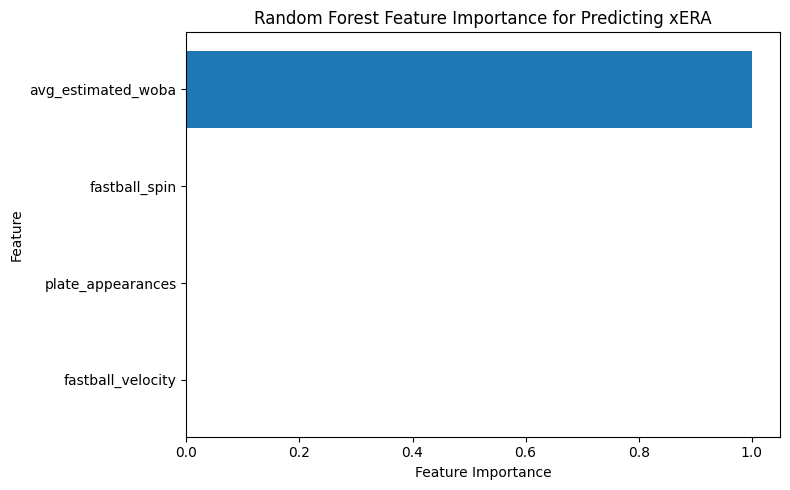

In [17]:
plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance for Predicting xERA")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Visualization: Actual vs. Predicted xERA

This visualization compares actual xERA values with predicted xERA values from the Random Forest model. A stronger model should produce points that fall closer to the diagonal reference line.

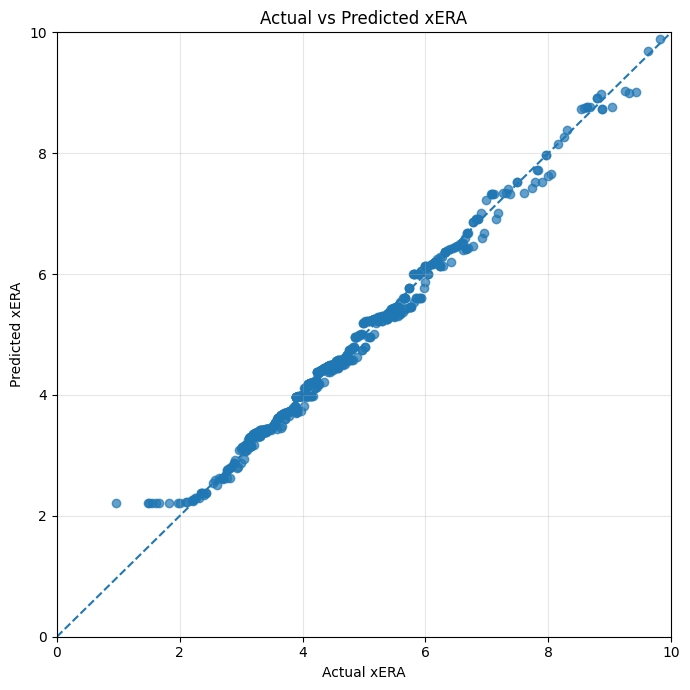

In [18]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(y_test, rf_predictions, alpha=0.7)

plt.plot([0, 10], [0, 10], linestyle="--")

plt.xlim(0, 10)
plt.ylim(0, 10)

ticks = np.arange(0, 10.1, 2)
plt.xticks(ticks)
plt.yticks(ticks)

plt.xlabel("Actual xERA")
plt.ylabel("Predicted xERA")
plt.title("Actual vs Predicted xERA")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
prediction_results = pd.DataFrame({
    "actual_xERA": y_test.values,
    "predicted_xERA": rf_predictions
})

prediction_results["residual"] = prediction_results["actual_xERA"] - prediction_results["predicted_xERA"]

display(prediction_results.head(10))

,actual_xERA,predicted_xERA,residual
0,2.88,2.866832,0.013168
1,11.80,11.311310,0.488690
2,37.28,44.085161,-6.805161
3,3.15,3.302089,-0.152089
4,3.47,3.438081,0.031919
5,3.42,3.433340,-0.013340
6,3.68,3.680063,-0.000063
7,2.99,3.113209,-0.123209
8,4.24,4.380253,-0.140253
9,2.88,2.866832,0.013168


## 12. Residual Analysis

Residuals measure the difference between actual xERA and predicted xERA. Smaller residuals indicate more accurate predictions.

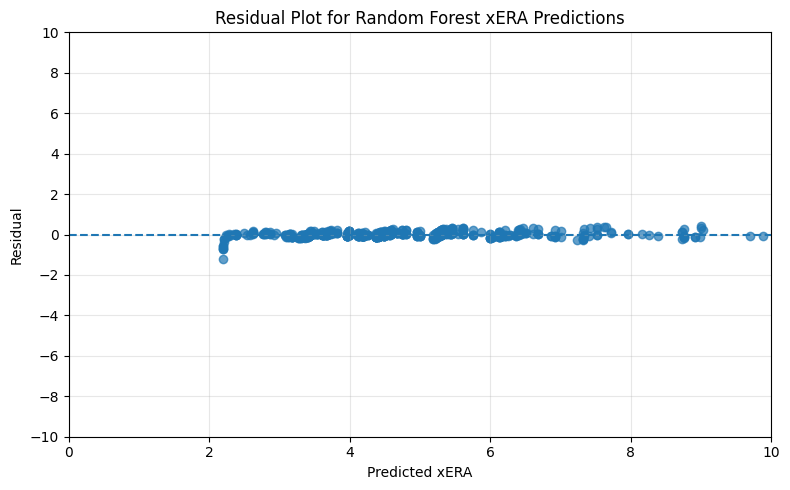

In [20]:
plt.figure(figsize=(8, 5))

plt.scatter(
    prediction_results["predicted_xERA"],
    prediction_results["residual"],
    alpha=0.7
)

plt.axhline(0, linestyle="--")

plt.xlim(0, 10)
plt.ylim(-10, 10)

plt.xticks(np.arange(0, 10.1, 2))
plt.yticks(np.arange(-10, 10.1, 2))

plt.xlabel("Predicted xERA")
plt.ylabel("Residual")
plt.title("Residual Plot for Random Forest xERA Predictions")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Analysis Rationale

The analysis begins by querying the MongoDB collection and converting the documents into a dataframe. This step demonstrates that the project uses MongoDB as the primary storage layer rather than relying only on local CSV files.

The model uses fastball velocity, fastball spin rate, and season as predictors of xERA. Velocity and spin rate are included because they are core pitch-quality metrics in Statcast analysis. Season is included to account for possible changes across the 2018–2021 period.

Linear regression is used as a baseline because it is interpretable and provides a simple comparison point. Random Forest is used as the main machine learning model because it can capture nonlinear relationships and interactions between predictors.

The model is evaluated using MAE, RMSE, and R². MAE and RMSE measure the size of prediction errors, while R² measures the share of variation in xERA explained by the model.

## 14. Visualization Rationale

The actual-versus-predicted xERA scatterplot is used because it directly shows whether the model is solving the prediction problem. If predicted values are close to actual values, the points should cluster near the diagonal reference line.

The residual plot is included to check whether prediction errors are randomly distributed or whether the model systematically overpredicts or underpredicts certain pitchers. These visualizations help evaluate both model accuracy and model limitations.

## 15. Conclusion

This pipeline shows how a MongoDB document database can support a predictive sports analytics workflow. The project begins with Statcast pitcher-season documents, queries them into Python, trains machine learning models, and visualizes prediction performance.

The results indicate whether Statcast pitch-quality metrics such as fastball velocity and spin rate contain useful information for predicting xERA. While the model may not explain all variation in pitcher performance, it provides a structured and reproducible way to connect pitch-quality data with expected run prevention.

In [21]:
logging.info("Pipeline completed successfully.")
print("Pipeline completed successfully.")

Pipeline completed successfully.
